In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Get the absolute path of the directory one level up (project root)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add it to sys.path if it's not already there
if project_root not in sys.path:
    sys.path.append(project_root)

# import SoilDataPreprocessor
from api.utils.preprocessing import SoilDataPreprocessor

import joblib

sns.set_style("darkgrid")

In [2]:
# Load the preprocessed dataset 

df = pd.read_csv("../data/data_for_fertilizer_classification.csv")

# Preview the first 10 rows of the data
df.head(10)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus,croprecommendation1,croprecommendation2,fertilizerrecommendation1,fertilizerrecommendation2
0,SILTY SOIL,4.9,0.14,22.9,0.14,1.1,1.3,2.2,1.2,10.1,5.6,VERY POOR,CASSAVA,COTTON,NPK,NPK
1,LOAMY SOIL,5.7,0.14,28.3,0.27,1.3,1.8,2.1,1.2,12.9,5.2,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
2,SILTY LOAM,5.9,0.16,23.1,0.39,2.1,1.6,2.5,1.2,10.1,6.4,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
3,LOAMY SOIL,5.7,0.20,29.2,0.47,2.1,2.8,2.2,1.2,12.0,7.4,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
4,LOAM,5.7,0.14,28.3,0.28,2.2,3.2,1.4,1.2,12.3,7.0,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
5,SILTY SAND,5.7,0.17,29.2,0.72,2.0,2.4,1.9,1.2,11.2,10.3,MODERATELY HEALTHY,SOYBEAN,SESAME,NPK,NPK
6,SILT,5.9,0.18,27.2,0.18,1.9,2.7,2.0,1.4,13.1,5.9,MODERATELY HEALTHY,BEANS,MAIZE,NPK,TSP
7,LOAM,5.7,0.16,22.9,1.22,1.2,2.2,1.5,1.7,12.4,9.4,MODERATELY HEALTHY,BANANA,ALVS,NPK,NPK
8,LOAMY SILT,5.6,0.15,19.4,0.72,1.3,1.9,2.2,1.2,12.6,8.7,POOR,BANANA,ALVS,NPK,NPK
9,LOAM,5.4,0.14,23.2,1.21,1.4,1.1,2.1,1.1,12.9,6.8,POOR,MAIZE,BEANS,NPK,TSP


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   simpliedtexture(1)         1000 non-null   object 
 1   ph                         1000 non-null   float64
 2   n                          1000 non-null   float64
 3   p                          1000 non-null   float64
 4   k                          1000 non-null   float64
 5   o                          1000 non-null   float64
 6   ca                         1000 non-null   float64
 7   mg                         1000 non-null   float64
 8   cu                         1000 non-null   float64
 9   fe                         1000 non-null   float64
 10  zn                         1000 non-null   float64
 11  soilfertilitystatus        1000 non-null   object 
 12  croprecommendation1        1000 non-null   object 
 13  croprecommendation2        1000 non-null   object

In [4]:
df['fertilizerrecommendation2'].value_counts()

fertilizerrecommendation2
NPK    820
TSP    180
Name: count, dtype: int64

Checking at the distribution of the fertiliser there is need for us to balance the class will use SMOTE for that

In [5]:
df = df.drop(columns=['croprecommendation1', 'croprecommendation2', 'fertilizerrecommendation1'])
df.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'fertilizerrecommendation2'],
      dtype='object')

In [6]:
preprocessor = SoilDataPreprocessor()

train_data_processed = preprocessor.fit_transform(
    df, 
    target_column='fertilizerrecommendation2',
    encoding_type='label',
    scaling_type='standard',
    apply_smote=False # False for to handle class imbalance natively with the models
)

2026-01-27 19:33:30,946 - SoilDataPreprocessor - INFO - SoilDataPreprocessor initialized
2026-01-27 19:33:30,951 - SoilDataPreprocessor - INFO - ============================================================
2026-01-27 19:33:30,953 - SoilDataPreprocessor - INFO - Starting fit_transform process
2026-01-27 19:33:30,955 - SoilDataPreprocessor - INFO - Parameters - encoding: label, scaling: standard, SMOTE: False
2026-01-27 19:33:30,957 - SoilDataPreprocessor - INFO - Input DataFrame shape: (1000, 13)
2026-01-27 19:33:30,960 - SoilDataPreprocessor - INFO - Target column: fertilizerrecommendation2
2026-01-27 19:33:30,962 - SoilDataPreprocessor - INFO - Target column data type: object
2026-01-27 19:33:30,963 - SoilDataPreprocessor - INFO - Target classes: ['NPK' 'TSP']
Overall Progress:   0%|          | 0/2 [00:00<?, ?step/s]2026-01-27 19:33:30,986 - SoilDataPreprocessor - INFO - ----------------------------------------
2026-01-27 19:33:30,988 - SoilDataPreprocessor - INFO - STEP 1: Categorica

In [7]:
# Save the fitted preprocessor
# preprocessor.save('models/soil_fertilizer_recommendation_preprocessor.joblib')

In [8]:
train_data_processed.sample(10)

,simpliedtexture(1),ph,n,p,k,o,ca,mg,cu,fe,zn,soilfertilitystatus,fertilizerrecommendation2
507,9,2.644434,0.020055,-0.784963,-0.789372,-0.747689,-0.472312,0.816037,1.057762,-0.419513,0.807409,0,0
328,9,0.234927,-0.021295,2.185387,0.971361,-0.044313,1.435148,-0.482007,1.571987,0.715840,0.456667,0,0
986,5,-0.281396,-0.062645,1.083483,0.513570,-0.747689,-0.964559,1.032378,0.543536,-1.100724,0.164381,1,0
282,7,-1.141934,-0.062645,-1.671277,0.443141,-0.325663,-0.841497,0.383356,0.543536,1.056446,-1.238589,2,0
931,9,0.062819,-0.062645,-1.168234,0.443141,-0.044313,5.373128,0.816037,-0.484915,-1.668401,-0.244818,0,0
767,8,0.407035,0.006271,0.939757,0.372712,-0.466338,-1.087621,1.032378,0.543536,1.056446,-0.712475,0,1
876,9,-0.109288,-0.021295,0.604394,0.443141,0.237038,-0.472312,1.032378,0.543536,0.488769,-0.712475,1,0
927,9,-0.625611,-0.062645,-1.192188,0.548785,-0.325663,0.450653,0.599696,-2.541816,1.056446,1.976551,1,0
575,9,1.611788,-0.021295,0.269032,0.443141,-0.466338,0.019936,0.167015,0.543536,0.488769,-0.654018,0,0
584,9,0.579142,-0.035079,0.987665,0.443141,-0.044313,0.512184,-1.563711,0.543536,0.261699,-0.654018,0,0


In [9]:
train_data_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   simpliedtexture(1)         1000 non-null   int64  
 1   ph                         1000 non-null   float64
 2   n                          1000 non-null   float64
 3   p                          1000 non-null   float64
 4   k                          1000 non-null   float64
 5   o                          1000 non-null   float64
 6   ca                         1000 non-null   float64
 7   mg                         1000 non-null   float64
 8   cu                         1000 non-null   float64
 9   fe                         1000 non-null   float64
 10  zn                         1000 non-null   float64
 11  soilfertilitystatus        1000 non-null   int64  
 12  fertilizerrecommendation2  1000 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 101.7 KB


In [10]:
train_data_processed['fertilizerrecommendation2'].value_counts()

fertilizerrecommendation2
0    820
1    180
Name: count, dtype: int64

Now we can see the dataset is balanced 

In [11]:
from sklearn.model_selection import train_test_split

X = train_data_processed.drop(columns=['fertilizerrecommendation2'])
y = train_data_processed['fertilizerrecommendation2']

print(f"X columns used: \n", X.columns)
print(f"\ny target columns:", y.name)

# splitting the dataset into train , test and validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=43)

X columns used: 
 Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus'],
      dtype='object')

y target columns: fertilizerrecommendation2


#### 1. Baseline Model

In [12]:
# Model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# model metrics libraries

from sklearn.metrics import ( 
    accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, confusion_matrix, 
    classification_report
)

In [13]:
# Logistic regression model
log_reg = LogisticRegression(class_weight='balanced', random_state=42)

# Fit the dataset
log_reg.fit(X_train, y_train)

# predict on the Test set
y_pred_log_reg = log_reg.predict(X_test)

In [14]:
# Model Evaluation for Logistic Regression
print("Logistic Regression:")

# Accuracy is the ratio of correctly predicted observation to the total observations.
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_log_reg, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_log_reg, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. Therefore, this score takes both false positives and false negatives into account.
print(f"F1 Score: {f1_score(y_test, y_pred_log_reg, average='macro'):.4f}")

Logistic Regression:
Accuracy: 0.6240
Precision: 0.6356
Recall: 0.6998
F1 Score: 0.5958


In [15]:
print("Classification report:\n", classification_report(y_test, y_pred_log_reg))

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.57      0.70       196
           1       0.35      0.83      0.49        54

    accuracy                           0.62       250
   macro avg       0.64      0.70      0.60       250
weighted avg       0.80      0.62      0.66       250



(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

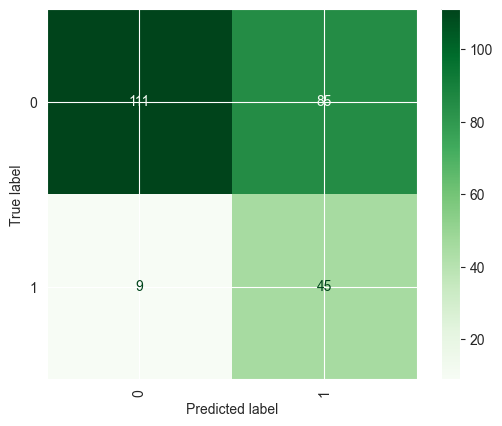

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log_reg, labels=log_reg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

# Saving the plot
# plot_path = '../eda_charts/models_evals/fertilize_log_reg_confusion_matrix.png'
# plt.savefig(plot_path)

In [17]:
df.columns

Index(['simpliedtexture(1)', 'ph', 'n', 'p', 'k', 'o', 'ca', 'mg', 'cu', 'fe',
       'zn', 'soilfertilitystatus', 'fertilizerrecommendation2'],
      dtype='object')

Multiclass AUROC Score (Macro Average) for Fertilizer Recommendation One vs Rest Logistic Regression Classifier: 0.7464


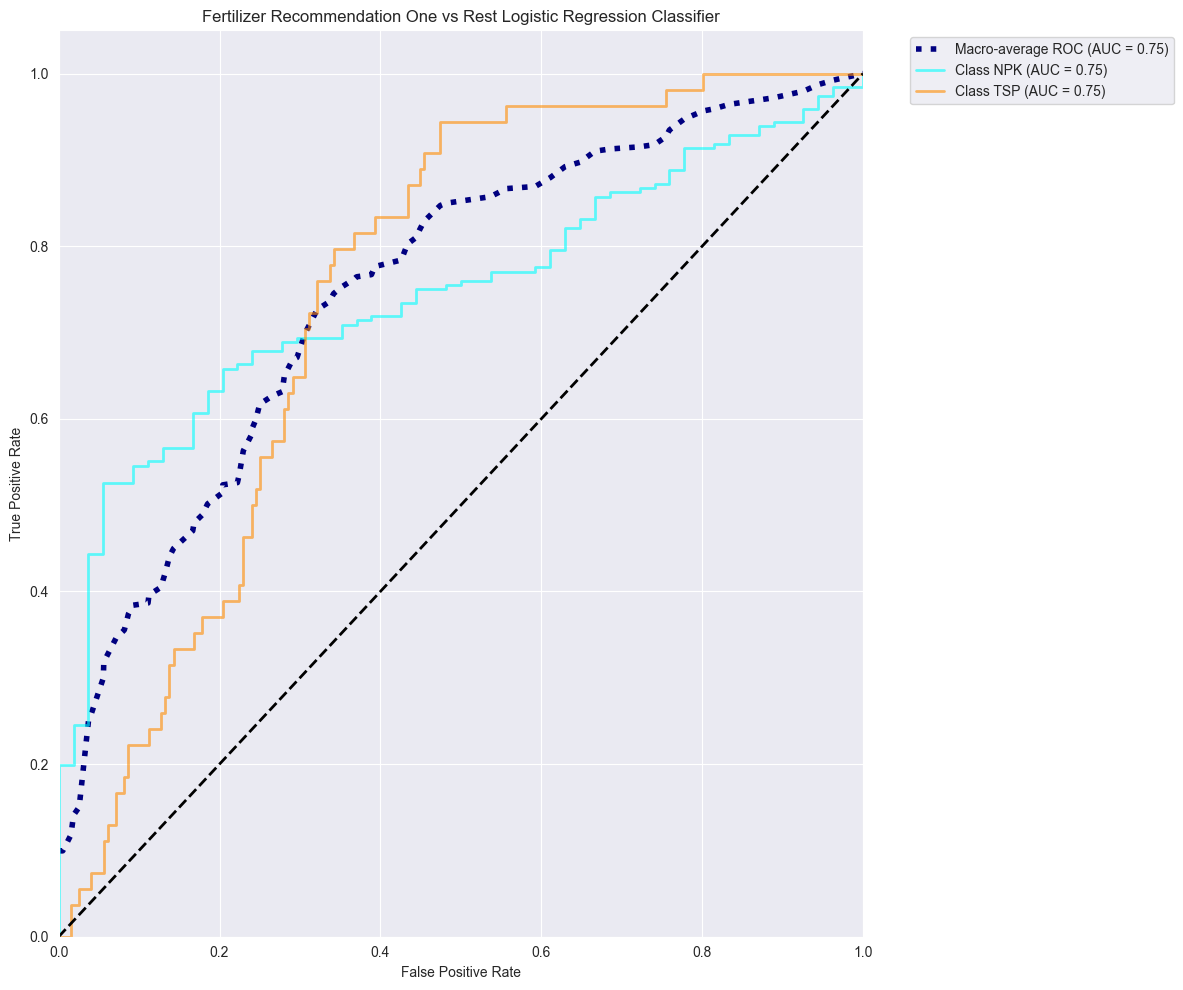

In [18]:
from sklearn.preprocessing import LabelEncoder
from notebooks_utils.auroc_evaluate import evaluate_and_plot_multiclass_roc

# 1. Re-fit the encoder on your original target column to get the names back
le = LabelEncoder()
le.fit(df['fertilizerrecommendation2'])

# 2. Get the class names
class_names = le.classes_ 

evaluate_and_plot_multiclass_roc(log_reg, X_test, y_test, class_names, title="Fertilizer Recommendation One vs Rest Logistic Regression Classifier")

#### 2. Decison Tree Model

In [19]:
# decision trees
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Fit the model on the training data
dtree.fit(X_train, y_train)

# Predict on the test set
y_pred_tree = dtree.predict(X_test)

In [20]:
print("Decision tree classifier:")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_tree, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_tree, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall.
print(f"F1 Score: {f1_score(y_test, y_pred_tree, average='macro'):.4f}")

Decision tree classifier:
Accuracy: 0.7280
Precision: 0.5452
Recall: 0.5314
F1 Score: 0.5311


In [21]:
print("Classification report:\n", classification_report(y_test, y_pred_tree))

Classification report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.83       196
           1       0.29      0.19      0.23        54

    accuracy                           0.73       250
   macro avg       0.55      0.53      0.53       250
weighted avg       0.69      0.73      0.70       250



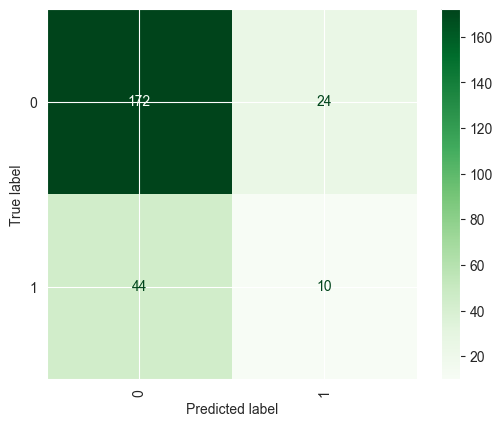

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tree, labels=dtree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

# Saving the plot
# plot_path = '../eda_charts/models_evals/fertiliser_decision_tree_confusion_matrix.png'
# plt.savefig(plot_path)

plt.show()

Multiclass AUROC Score (Macro Average) for Fertilizer Recommendation Decision Tree Classifier: 0.5314


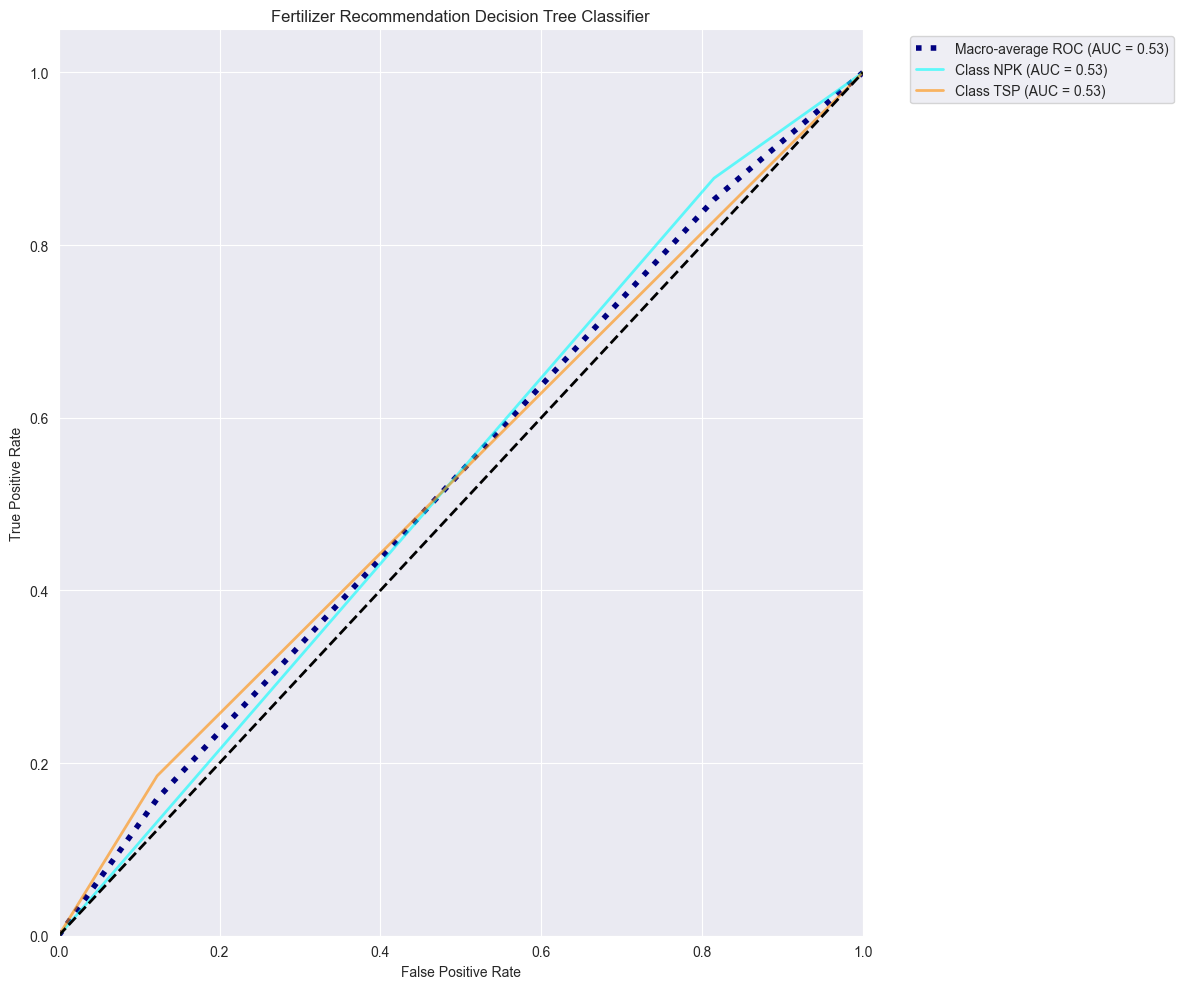

In [23]:
evaluate_and_plot_multiclass_roc(dtree, X_test, y_test, class_names, title="Fertilizer Recommendation Decision Tree Classifier")

In [24]:
# Save the model to a file

# joblib.dump(dtree, 'models/Fertilizer_decisionTree_Classifier_model.joblib')

# print("Decision Tree Classifier models saved to: models/Fertiliser_decisionTree_Classifier_model")

#### 3. Random Forest

In [24]:
# Random forest classifier

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(class_weight='balanced_subsample', random_state=142)

# Fit the model
rf.fit(X_train, y_train)

# Make predictions on test set
y_pred_rf = rf.predict(X_test)

In [25]:
# Model Evaluation for Random Forest
print("\nRandom Forest:")

# Accuracy is the proportion of true results (both true positives and true negatives) among the total number of cases examined.
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")

# Precision is the ratio of correctly predicted positive observations to the total predicted positives.
print(f"Precision: {precision_score(y_test, y_pred_rf, average='macro'):.4f}")

# Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class.
print(f"Recall: {recall_score(y_test, y_pred_rf, average='macro'):.4f}")

# F1 Score is the weighted average of Precision and Recall. It tries to find the balance between precision and recall.
print(f"F1 Score: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")


Random Forest:
Accuracy: 0.78
Precision: 0.6093
Recall: 0.5176
F1 Score: 0.4865


In [26]:
print("Classification report:\n", classification_report(y_test, y_pred_rf))

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.98      0.87       196
           1       0.43      0.06      0.10        54

    accuracy                           0.78       250
   macro avg       0.61      0.52      0.49       250
weighted avg       0.71      0.78      0.71       250



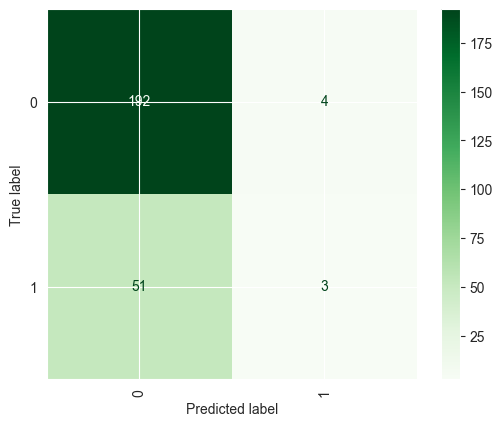

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

# Saving the plot
# plot_path = 'eda_charts/models_evals/Fertiliser_random_forest_confusion_matrix.png'
# plt.savefig(plot_path)

plt.show()

Multiclass AUROC Score (Macro Average) for Fertilizer Recommendation Random Forest Classifier: 0.7612


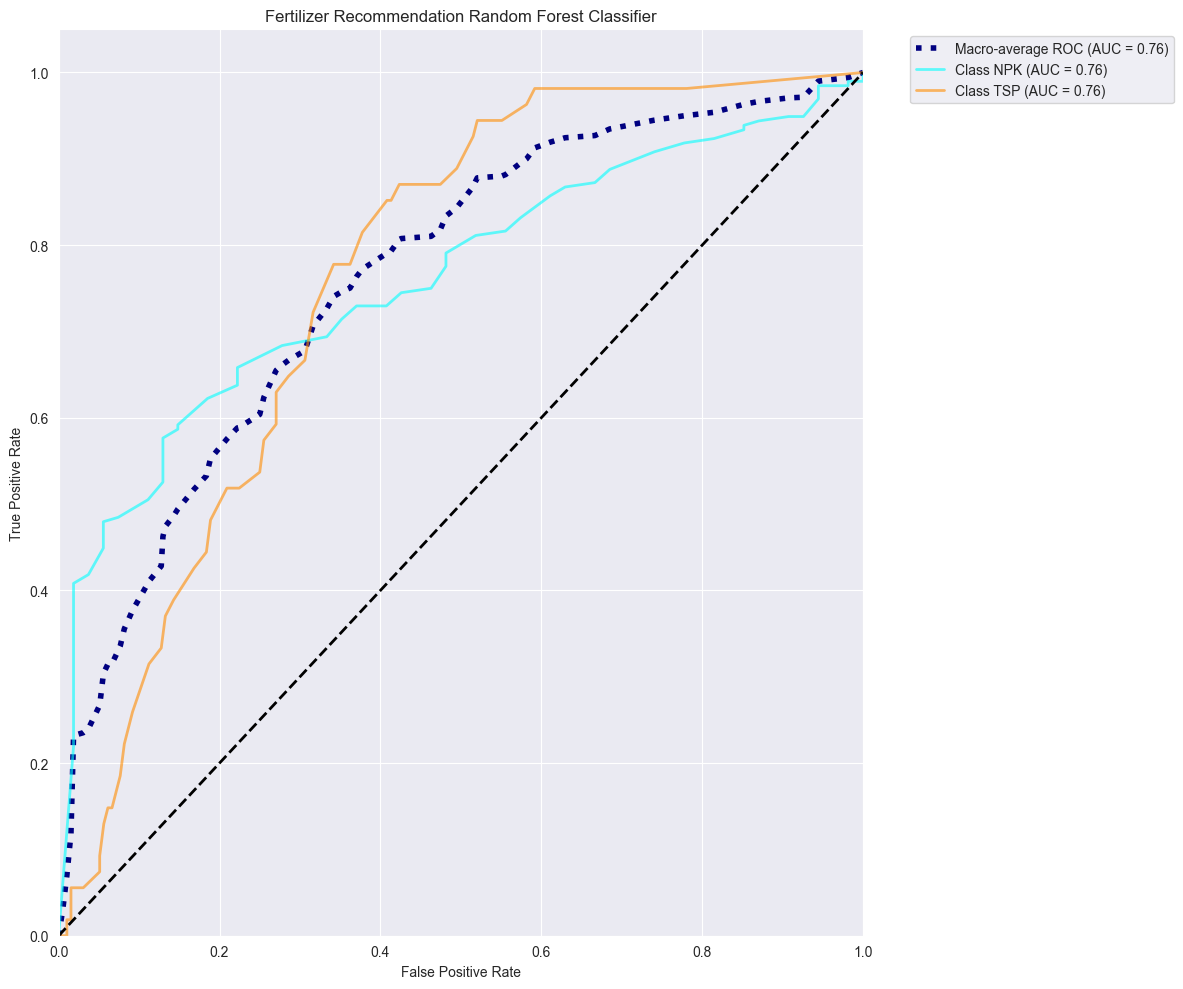

In [28]:
evaluate_and_plot_multiclass_roc(rf, X_test, y_test, class_names, title="Fertilizer Recommendation Random Forest Classifier")

In [29]:
# Save the model to a file

# joblib.dump(rf, "models/Fertilizer_randomForest_Classifier_Model.joblib")

# print("Random Forest Classifier saved to: models/Fertiliser_randomForest_Classifier")

#### 4. Gradient Boosting Machine

In [30]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [31]:
# xg boost for fertilizer classification

# initialise the model
xgb = XGBClassifier(random_state=142)

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Fit the model on training data
xgb.fit(X_train, y_train, sample_weight=sample_weights)

# predict the test set
y_pred_xgb = xgb.predict(X_test)

In [32]:
# Model Evaluation for XGBoost
print("\nGradient Boosting Machine (XGBoost):")

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

print(f"Precision: {precision_score(y_test, y_pred_xgb, average='macro'):.4f}")

print(f"Recall: {recall_score(y_test, y_pred_xgb, average='macro'):.4f}")

print(f"F1 Score: {f1_score(y_test, y_pred_xgb, average='macro'):.4f}")


Gradient Boosting Machine (XGBoost):
Accuracy: 0.7480
Precision: 0.6122
Recall: 0.5978
F1 Score: 0.6033


In [33]:
print("Classification report:\n", classification_report(y_test, y_pred_xgb))

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       196
           1       0.40      0.33      0.36        54

    accuracy                           0.75       250
   macro avg       0.61      0.60      0.60       250
weighted avg       0.73      0.75      0.74       250



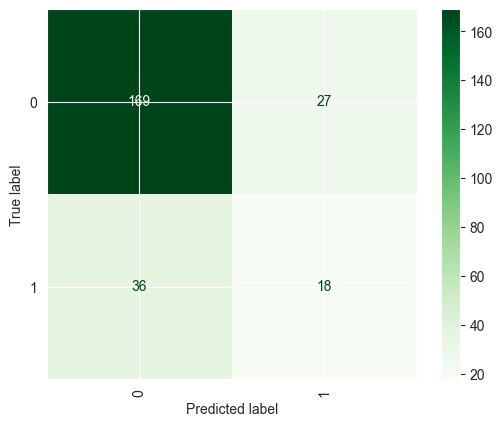

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb, labels=xgb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb.classes_)
disp.plot(cmap='Greens')
plt.xticks(rotation=90)

# Saving the plot
# plot_path = 'eda_charts/models_evals/Fertiliser_xgboost_confusion_matrix.png'
# plt.savefig(plot_path)

plt.show()

Multiclass AUROC Score (Macro Average) for Fertilizer Recommendation XG-Boost Classifier: 0.7302


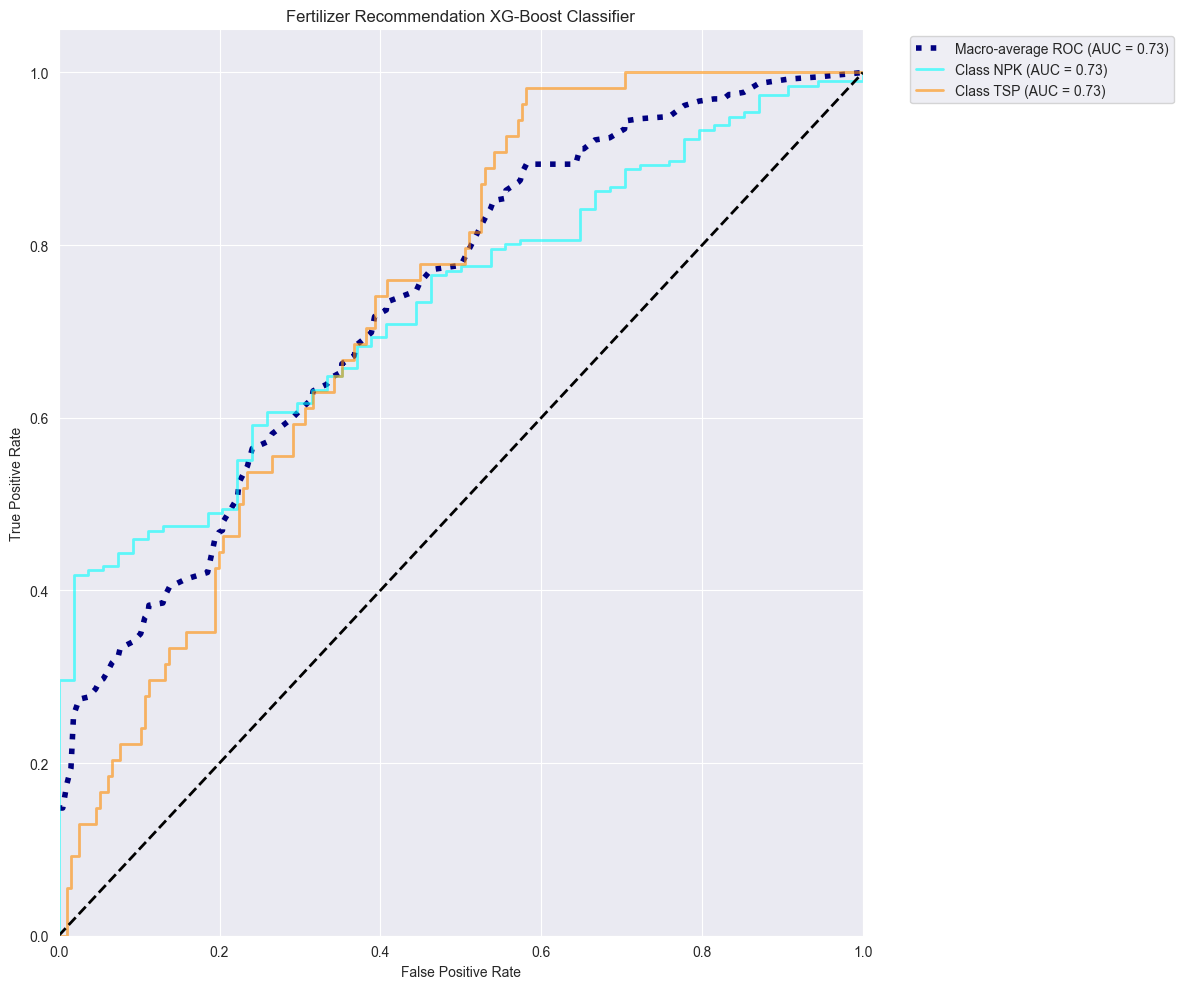

In [36]:
evaluate_and_plot_multiclass_roc(xgb, X_test, y_test, class_names, title="Fertilizer Recommendation XG-Boost Classifier")

In [36]:
# Save the model to a file

# joblib.dump(xgb, "models/Fertilizers_xgb_Classifier_Model.joblib")

# print("Gradient Boosting Classifier saved to: models/Fertiliser_xgboost_Classifier")